# Best Predictions Attribution Heatmap

Finds the 10 sequences where the model predicts the longest suffix correctly,
then visualizes their attributions using the suffix heatmap approach.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from tqdm.auto import tqdm

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [ ]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}, Suffix length: {model.seq_len_pred}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [ ]:
def get_ground_truth_suffix(case, prefix_len, eval_helper):
    """Extract ground truth suffix activities from case."""
    concept_id = eval_helper.concept_name_id
    eos_id = eval_helper.eos_id
    inverted_cats = eval_helper.inverted_suffix_categories[concept_id]
    
    activities = case[0][concept_id]
    suffix = []
    for i in range(prefix_len, activities.shape[0]):
        act_id = activities[i].item()
        if act_id == eos_id:
            break
        if act_id in inverted_cats:
            suffix.append(inverted_cats[act_id])
    return suffix

def compare_suffixes(predicted, ground_truth):
    """Count how many activities match from the start."""
    correct = 0
    for p, g in zip(predicted, ground_truth):
        pred_act = p.get(CONFIG.concept_name) if isinstance(p, dict) else p
        if pred_act == g:
            correct += 1
        else:
            break
    return correct

def find_best_predictions(eval_helper, top_k=10):
    """Find cases with longest correctly predicted suffixes."""
    results = []
    
    for case_name, case in tqdm(eval_helper.cases.items(), desc="Evaluating cases"):
        for prefix_len, prefix, suffix in eval_helper._iterate_case(case):
            # Get ground truth
            gt_suffix = get_ground_truth_suffix(case, prefix_len, eval_helper)
            if not gt_suffix:
                continue
            
            # Predict suffix
            try:
                pred_suffix = eval_helper._predict_suffix_with_means(prefix, prefix_len)
            except Exception:
                continue
            
            # Compare
            correct_len = compare_suffixes(pred_suffix, gt_suffix)
            
            if correct_len > 0:
                results.append({
                    'case_name': case_name,
                    'prefix_len': prefix_len,
                    'correct_len': correct_len,
                    'gt_suffix': gt_suffix[:correct_len],
                    'pred_suffix': [p.get(CONFIG.concept_name) for p in pred_suffix[:correct_len]],
                    'prefix': prefix
                })
    
    # Sort by correct length (descending), then prefix length (ascending for diversity)
    results.sort(key=lambda x: (-x['correct_len'], x['prefix_len']))
    
    # Take top_k unique cases
    seen_cases = set()
    unique_results = []
    for r in results:
        if r['case_name'] not in seen_cases:
            seen_cases.add(r['case_name'])
            unique_results.append(r)
        if len(unique_results) >= top_k:
            break
    
    return unique_results

print("Finding best predictions...")
best_predictions = find_best_predictions(eval_helper, top_k=10)
print(f"\nTop {len(best_predictions)} predictions:")
for i, r in enumerate(best_predictions, 1):
    print(f"{i}. {r['case_name']}: prefix={r['prefix_len']}, correct_suffix_len={r['correct_len']}")
    print(f"   Suffix: {' -> '.join(r['pred_suffix'])}")

Finding best predictions...


Evaluating cases:   0%|          | 0/6301 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def compute_suffix_attributions(tool, prefix, prefix_len, target, n_steps=50):
    """Compute IG attributions for all suffix steps."""
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results, feature_names, prefix_labels = [], None, None
    
    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names, prefix_labels = attr_map.feature_names, attr_map.step_labels
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Step {suffix_step} error: {e}")
            break
    
    return results, feature_names, prefix_labels

def build_cube_and_reduce(results, feature_names, prefix_labels):
    """Build 3D cube and reduce to 2D by selecting top 2 features."""
    n_features = len(feature_names)
    n_suffix = len(results)
    n_prefix = len(prefix_labels)
    
    cube = np.full((n_features, n_prefix, n_suffix), np.nan)
    suffix_labels = []
    
    for suffix_step, attr_map, pred_desc in results:
        suffix_labels.append(pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {suffix_step}")
        
        for feat_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else vals
                cube[feat_idx, :len(vals), suffix_step] = vals
    
    magnitude_1st = np.full((n_prefix, n_suffix), np.nan)
    magnitude_2nd = np.full((n_prefix, n_suffix), np.nan)
    feature_name_1st = np.empty((n_prefix, n_suffix), dtype=object)
    feature_name_2nd = np.empty((n_prefix, n_suffix), dtype=object)
    
    for p in range(n_prefix):
        for s in range(n_suffix):
            if not np.all(np.isnan(cube[:, p, s])):
                abs_vals = np.abs(cube[:, p, s])
                sorted_idx = np.argsort(abs_vals)[::-1]
                
                feat_idx_1 = sorted_idx[0]
                magnitude_1st[p, s] = cube[feat_idx_1, p, s]
                feature_name_1st[p, s] = feature_names[feat_idx_1]
                
                if len(sorted_idx) > 1:
                    feat_idx_2 = sorted_idx[1]
                    magnitude_2nd[p, s] = cube[feat_idx_2, p, s]
                    feature_name_2nd[p, s] = feature_names[feat_idx_2]
    
    return magnitude_1st, magnitude_2nd, feature_name_1st, feature_name_2nd, suffix_labels, prefix_labels, cube

In [ ]:
def plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels, case_name, correct_len):
    """Plot 2D heatmap showing top 2 features at each position."""
    data = mag_1st.T
    n_suffix, n_positions = data.shape
    
    fig, ax = plt.subplots(figsize=(max(12, n_positions * 2.5), max(5, n_suffix * 2.5)))
    
    masked_data = np.ma.masked_invalid(data)
    vmax = max(np.nanmax(np.abs(data)), 0.001)
    
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='lightgray')
    im = ax.imshow(masked_data, cmap=cmap, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                   aspect='auto', interpolation='nearest')
    
    for i in range(n_suffix):
        for j in range(n_positions):
            if not np.isnan(data[i, j]):
                feat1 = feat_1st.T[i, j]
                val1 = mag_1st.T[i, j]
                feat2 = feat_2nd.T[i, j]
                val2 = mag_2nd.T[i, j]
                
                color = 'white' if abs(val1) > vmax * 0.5 else 'black'
                
                text = f"{feat1}\n{val1:.3f}"
                if feat2 is not None and not np.isnan(val2):
                    text += f"\n({feat2}: {val2:.3f})"
                
                ax.text(j, i, text, ha='center', va='center',
                       color=color, fontsize=7, fontweight='bold')
    
    ax.set_xticks(range(n_positions))
    ax.set_xticklabels([l[:15] + '..' if len(l) > 15 else l for l in step_labels], rotation=45, ha='right')
    ax.set_yticks(range(n_suffix))
    ax.set_yticklabels(suffix_labels)
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Suffix Predictions')
    ax.set_title(f'{case_name} - {correct_len} correct predictions\nTop 2 features (1st bold, 2nd in parentheses)')
    plt.colorbar(im, ax=ax, label='Attribution', shrink=0.8)
    ax.grid(False)
    plt.tight_layout()
    return fig


#1: Case 1261 (prefix=1, correct=4)
Suffix: Take in charge ticket -> Take in charge ticket -> Resolve ticket -> Closed


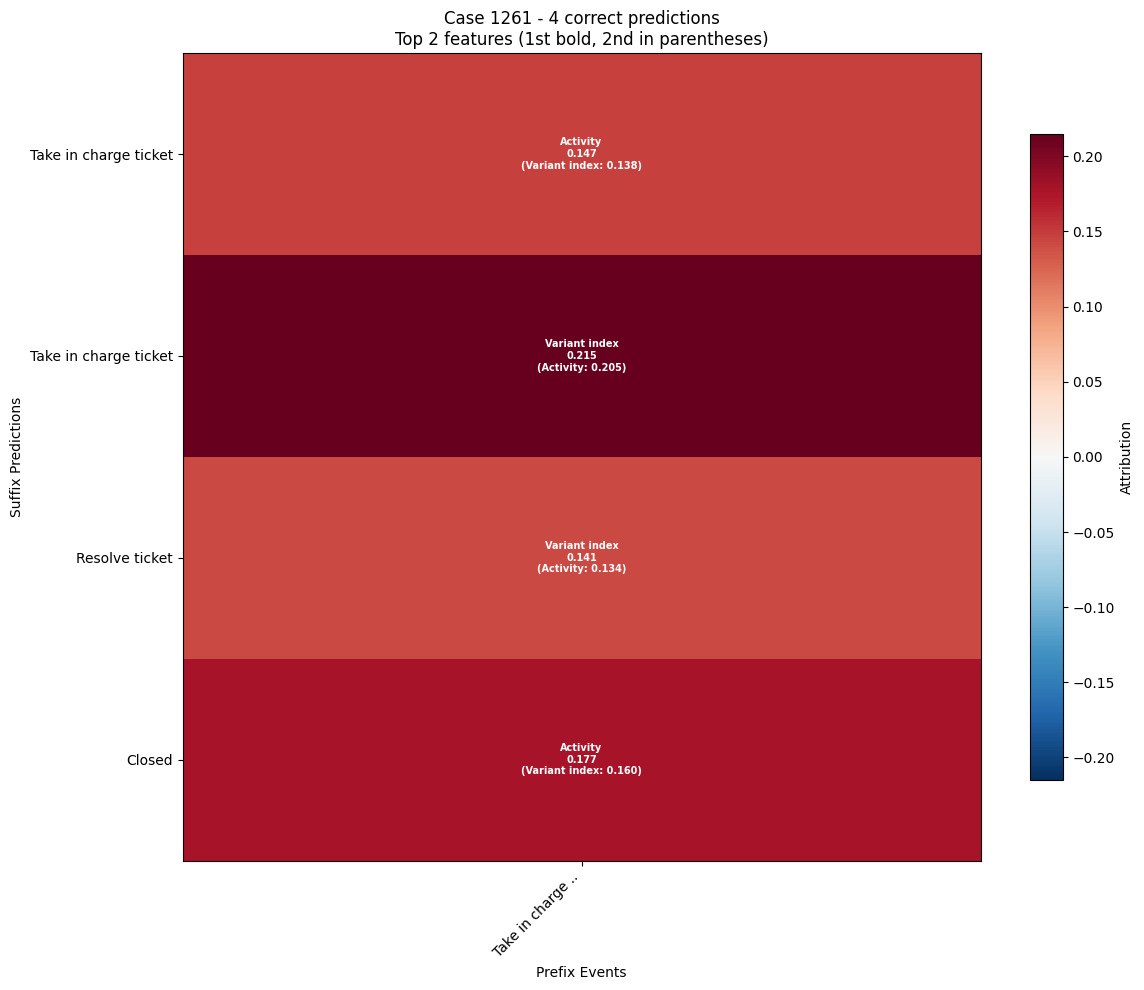


#2: Case 1501 (prefix=1, correct=2)
Suffix: Take in charge ticket -> Resolve ticket


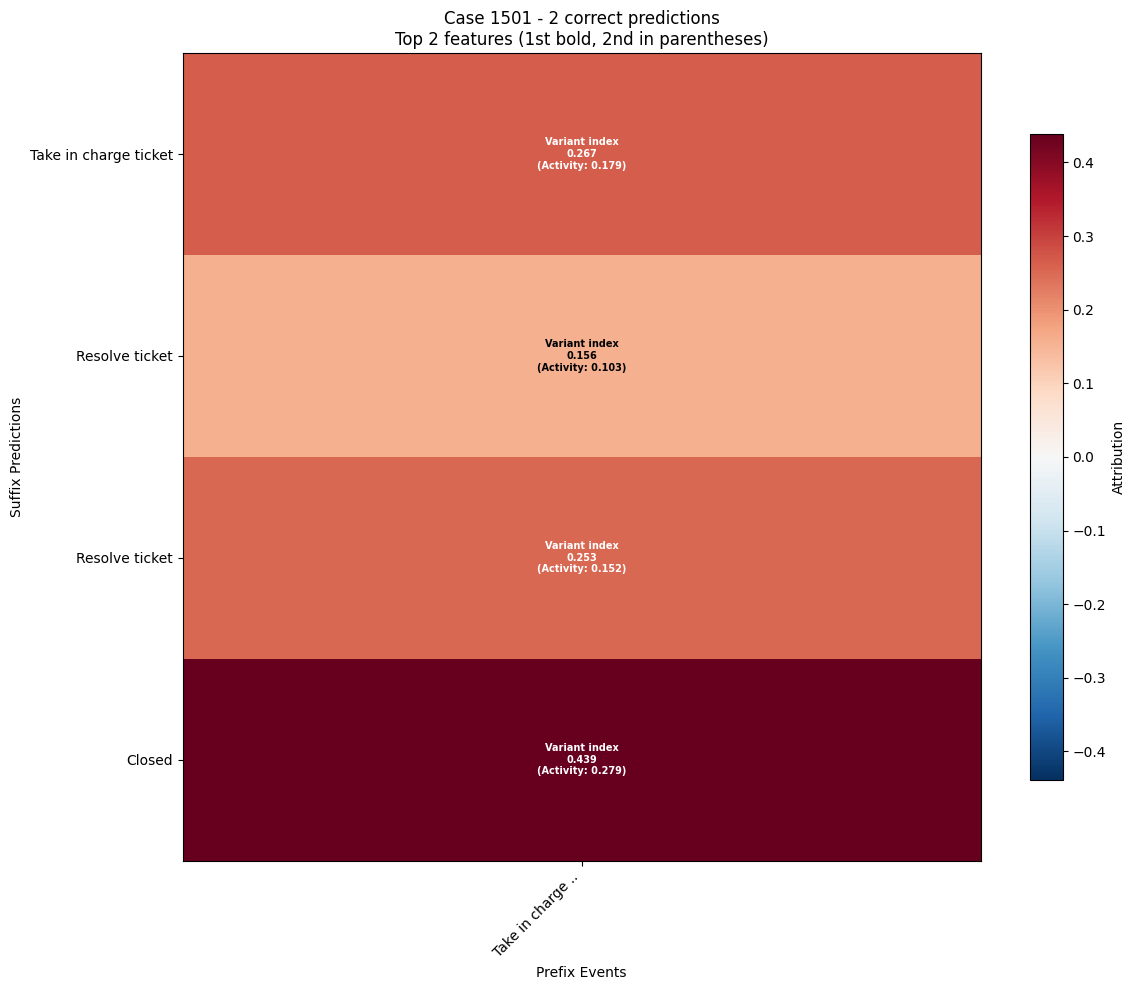


#3: Case 1664 (prefix=1, correct=2)
Suffix: Take in charge ticket -> Resolve ticket


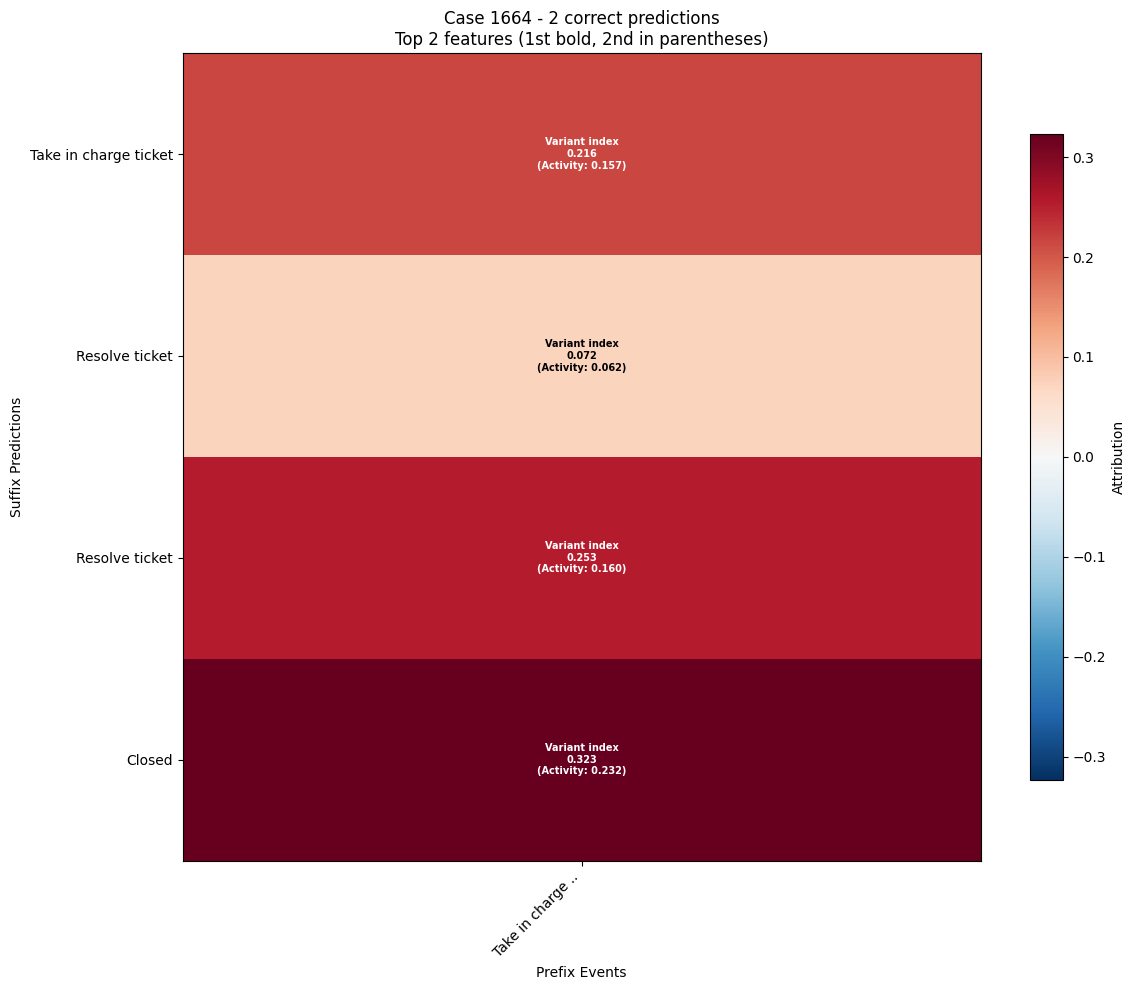


#4: Case 2686 (prefix=1, correct=2)
Suffix: Take in charge ticket -> Resolve ticket


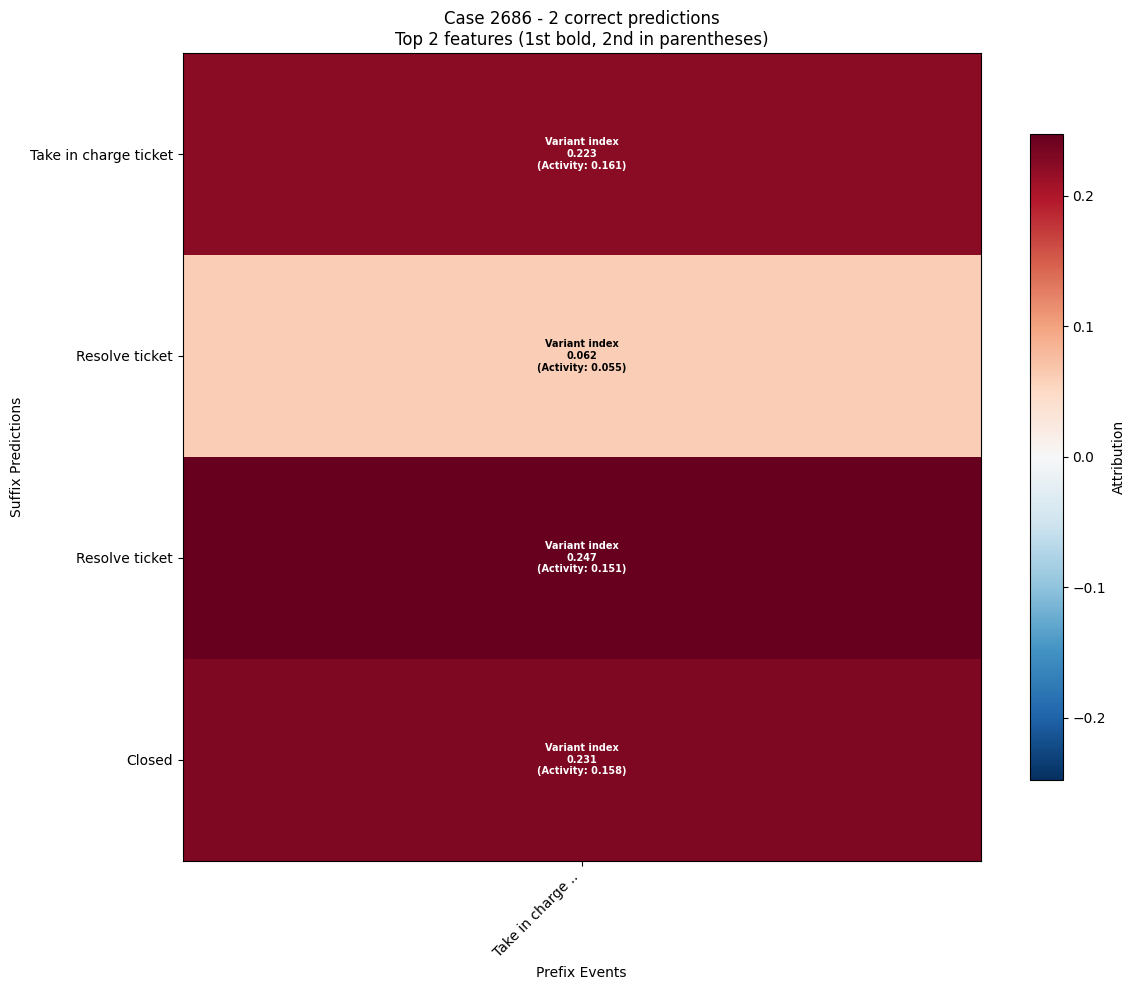


#5: Case 4367 (prefix=1, correct=2)
Suffix: Take in charge ticket -> Resolve ticket


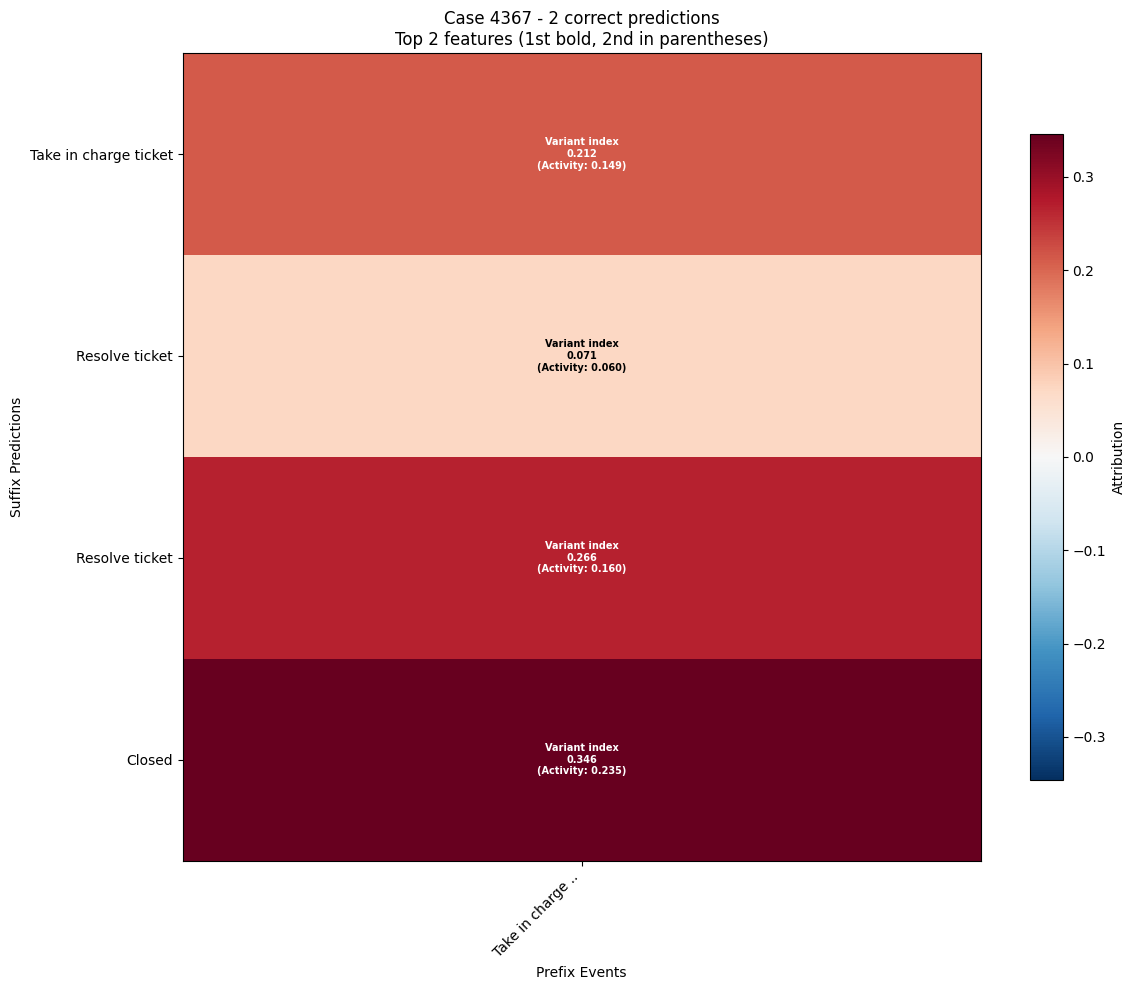


#6: Case 2253 (prefix=1, correct=1)
Suffix: Take in charge ticket


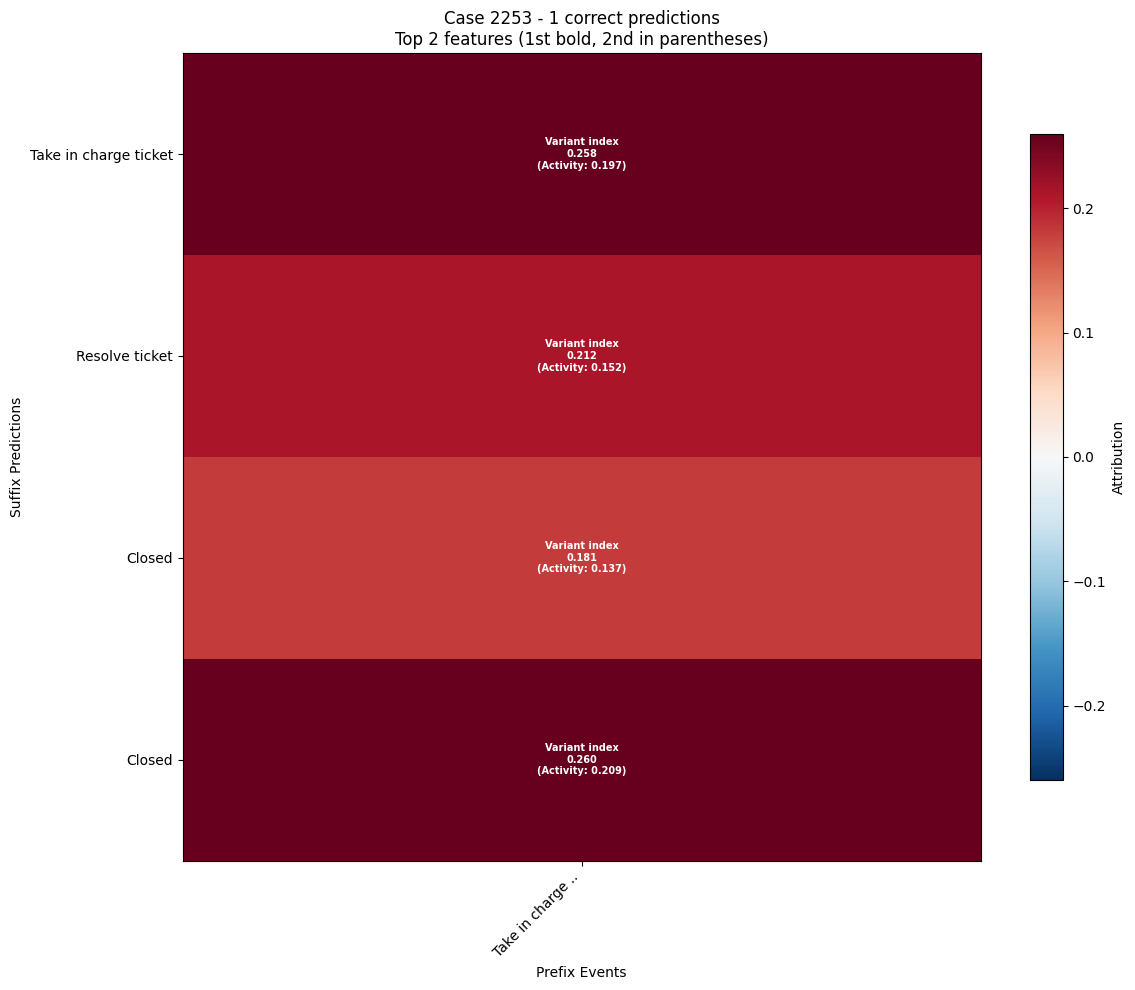


#7: Case 2400 (prefix=1, correct=1)
Suffix: Take in charge ticket


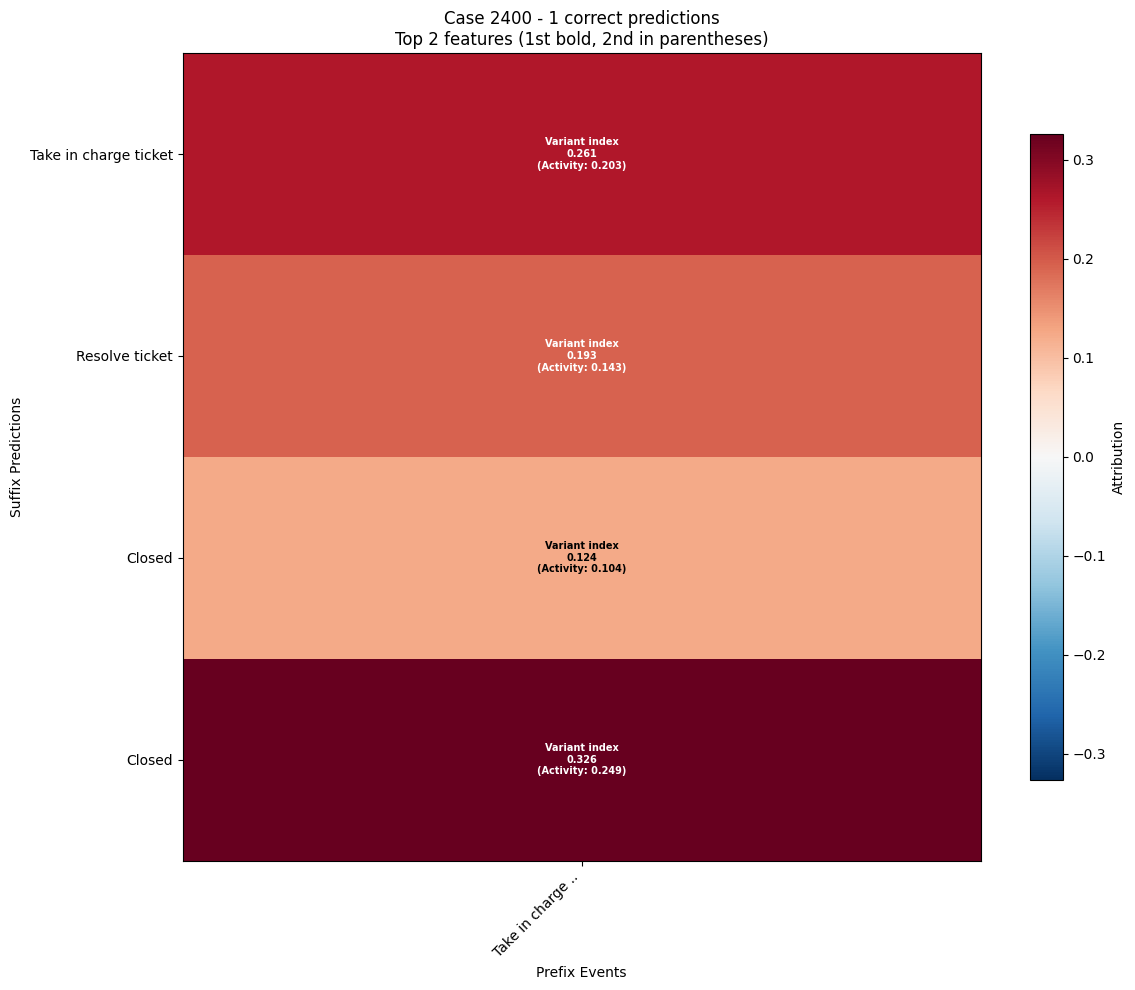


#8: Case 2753 (prefix=1, correct=1)
Suffix: Take in charge ticket


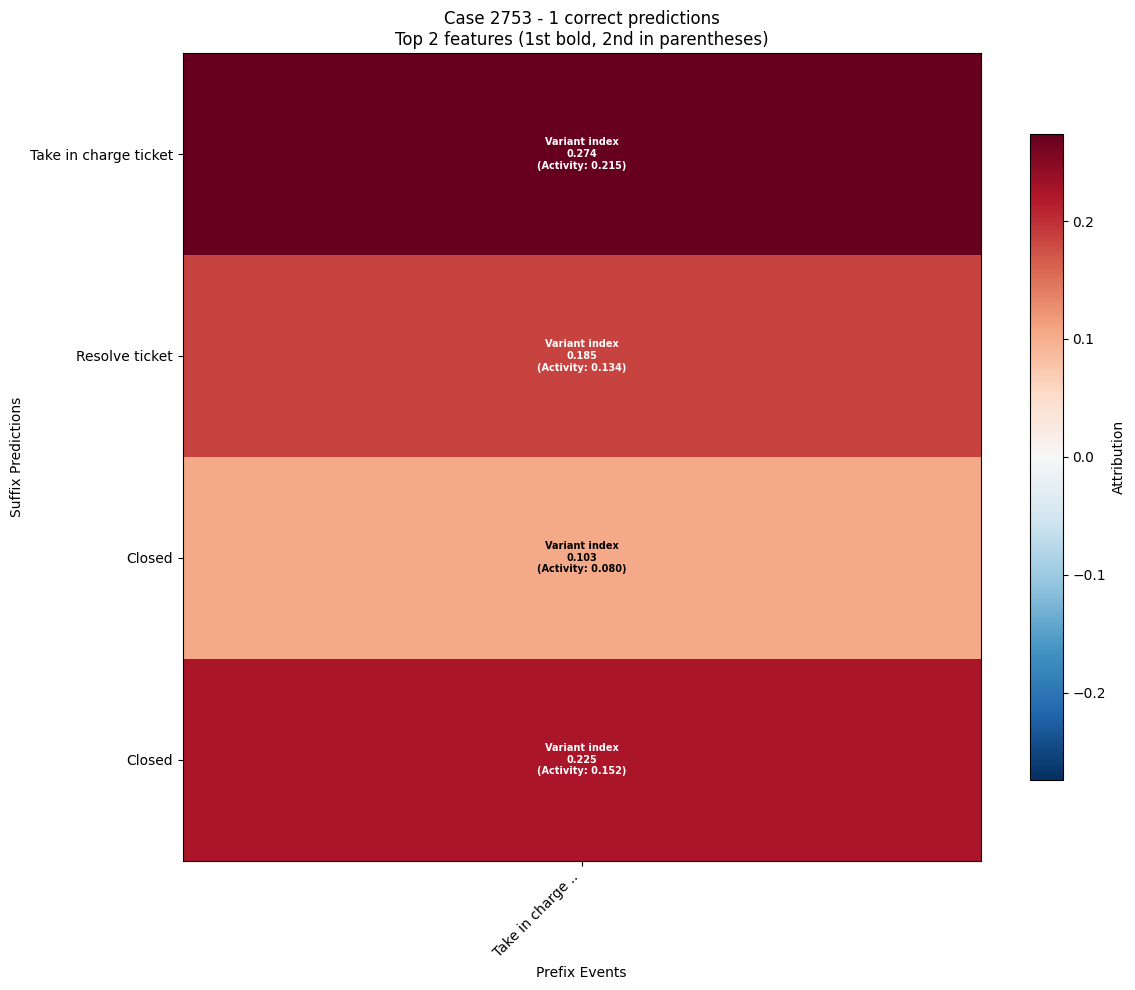


#9: Case 2776 (prefix=1, correct=1)
Suffix: Take in charge ticket


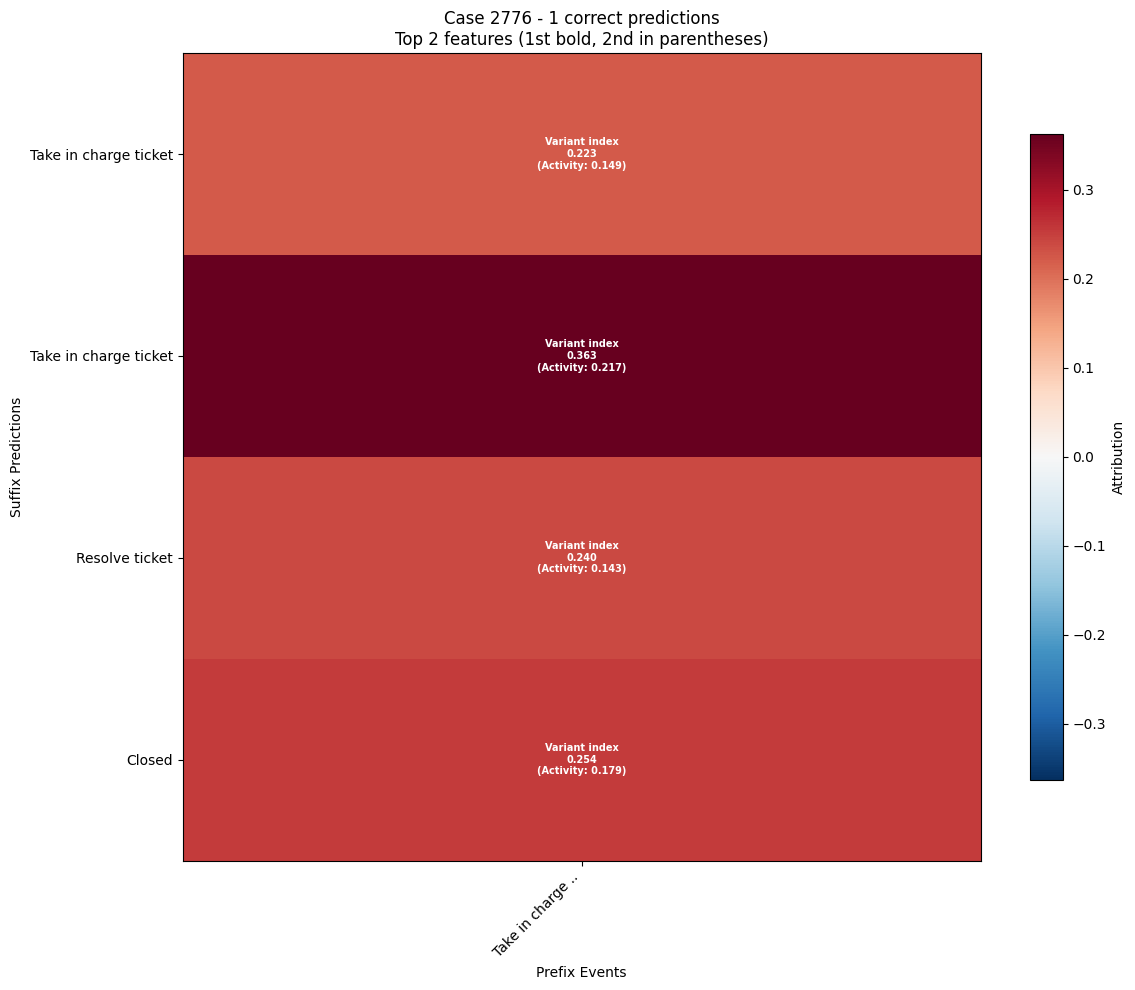


#10: Case 3011 (prefix=1, correct=1)
Suffix: Take in charge ticket


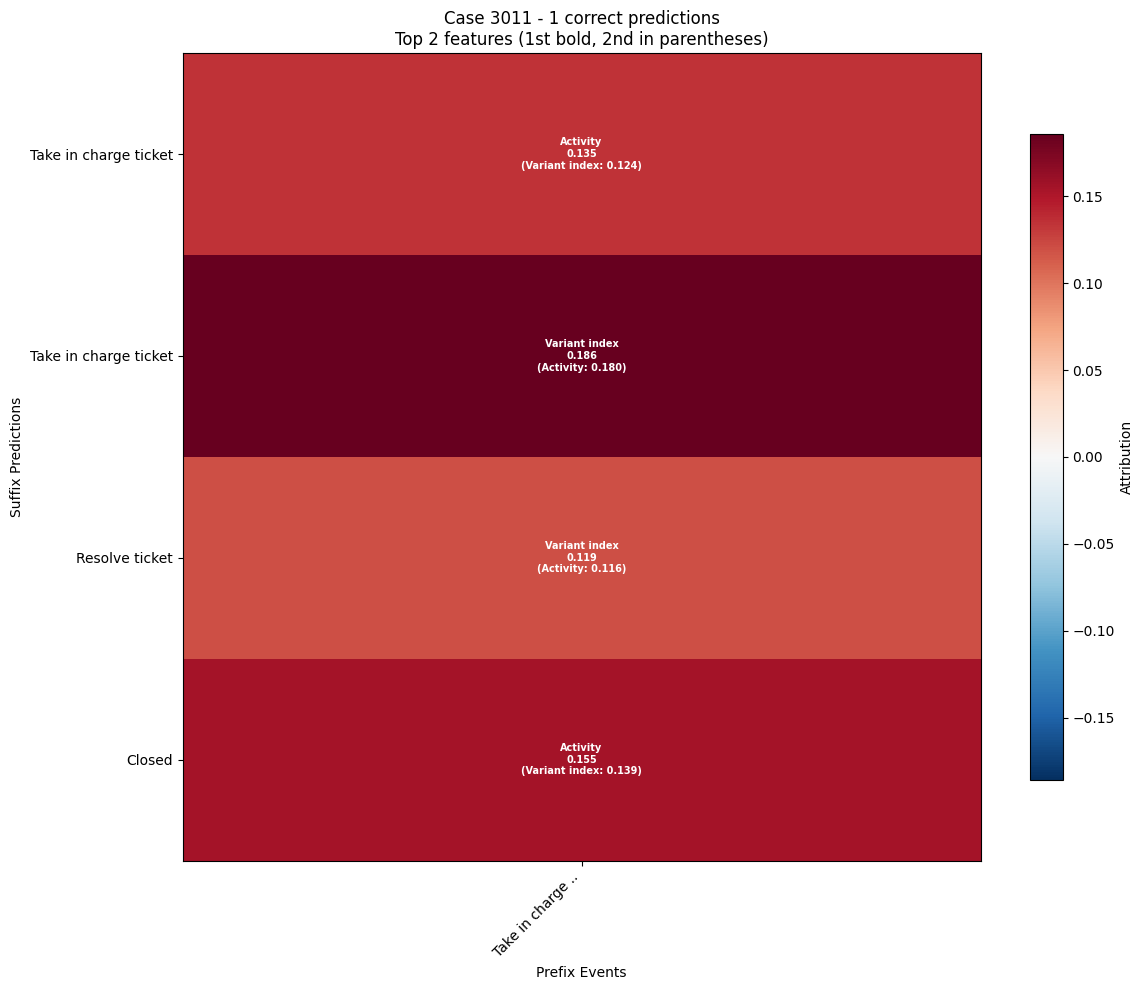

In [ ]:
# Visualize top predictions
for i, pred in enumerate(best_predictions, 1):
    print(f"\n{'='*60}")
    print(f"#{i}: {pred['case_name']} (prefix={pred['prefix_len']}, correct={pred['correct_len']})")
    print(f"Suffix: {' -> '.join(pred['pred_suffix'])}")
    print(f"{'='*60}")
    
    results, feature_names, prefix_labels = compute_suffix_attributions(
        tool, pred['prefix'], pred['prefix_len'], CONFIG.concept_name, n_steps=CONFIG.ig_steps
    )
    
    if results and feature_names:
        mag_1st, mag_2nd, feat_1st, feat_2nd, suffix_labels, step_labels, cube = build_cube_and_reduce(
            results, feature_names, prefix_labels
        )
        
        fig = plot_suffix_heatmap(
            mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels,
            pred['case_name'], pred['correct_len']
        )
        plt.show()
    else:
        print("  No attributions computed")

In [ ]:
# Summary statistics
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
correct_lens = [p['correct_len'] for p in best_predictions]
prefix_lens = [p['prefix_len'] for p in best_predictions]
print(f"Correct suffix lengths: {correct_lens}")
print(f"Prefix lengths: {prefix_lens}")
print(f"Avg correct: {np.mean(correct_lens):.1f}, Max: {max(correct_lens)}")


SUMMARY
Correct suffix lengths: [4, 2, 2, 2, 2, 1, 1, 1, 1, 1]
Prefix lengths: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Avg correct: 1.7, Max: 4
